In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


In [4]:
import pulp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Market & Ancillary Service Parameters (Day-Ahead + FCR Co-Optimization)
hours = range(24)

# EPEX Spot Day-Ahead Prices (€/MWh), featuring negative price windows
prices_da = [40, 30, 20, 10, 2, -15, -45, -20, 5, 30, 70, 95,
             110, 85, 40, 20, 15, 60, 120, 150, 130, 95, 70, 50]

# FCR (Frequency Containment Reserve) Hourly Capacity Prices (€/MW/h)
prices_fcr = [12.0] * 24

# Dynamic grid export limits (MW) restricting energy injection during solar peaks
grid_export_limit = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.3, 0.1, 0.4, 1.0, 1.0, 1.0,
                     0.0, 0.0, 0.2, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

# Battery technical specifications
max_power = 1.0          # Max inverter power rating (MW)
max_capacity = 2.0       # Max energy storage capacity (MWh)
efficiency = 0.92        # Round-trip efficiency
degradation_cost = 5.0   # Wear-and-tear cost per MWh throughput (€/MWh)
fcr_capacity_req = 0.3   # Fixed minimum FCR capacity commitment obligation (MW)

# 2. Mixed-Integer Linear Programming (MILP) Multi-Market Co-Optimization Model
prob = pulp.LpProblem("BESS_Multi_Market_CoOptimization", pulp.LpMaximize)

# Decision Variables
P_charge = {t: pulp.LpVariable(f"P_charge_{t}", lowBound=0, upBound=max_power) for t in hours}
P_discharge = {t: pulp.LpVariable(f"P_discharge_{t}", lowBound=0, upBound=max_power) for t in hours}
R_fcr = {t: pulp.LpVariable(f"R_fcr_{t}", lowBound=fcr_capacity_req, upBound=max_power) for t in hours}
SoC = {t: pulp.LpVariable(f"SoC_{t}", lowBound=0.1 * max_capacity, upBound=0.9 * max_capacity) for t in hours}
u = {t: pulp.LpVariable(f"u_{t}", cat='Binary') for t in hours}

# Objective Function: Maximize (DA Energy Arbitrage + FCR Capacity Revenue - Degradation Cost)
revenue_da = pulp.lpSum([prices_da[t] * (P_discharge[t] - P_charge[t]) for t in hours])
revenue_fcr = pulp.lpSum([prices_fcr[t] * R_fcr[t] for t in hours])
cost_deg = pulp.lpSum([degradation_cost * (P_charge[t] + P_discharge[t]) for t in hours])

prob += revenue_da + revenue_fcr - cost_deg

# 3. Constraints Formulation
initial_soc = 1.0
for t in hours:
    # Power capacity joint constraints: Energy dispatch + FCR reserve headroom <= Inverter max power
    prob += P_discharge[t] + R_fcr[t] <= max_power
    prob += P_charge[t] + R_fcr[t] <= max_power

    # Grid export limit restriction
    prob += P_discharge[t] <= grid_export_limit[t]

    # Mutual exclusivity binary logic to prevent simultaneous charging and discharging
    prob += P_charge[t] <= max_power * u[t]
    prob += P_discharge[t] <= max_power * (1 - u[t])

    # State of Charge (SoC) dynamics accounting for energy throughput and FCR energy buffer requirements
    if t == 0:
        prob += SoC[t] == initial_soc + (P_charge[t] * efficiency) - (P_discharge[t] / efficiency)
    else:
        prob += SoC[t] == SoC[t-1] + (P_charge[t] * efficiency) - (P_discharge[t] / efficiency)

# Solve optimization problem
prob.solve(pulp.PULP_CBC_CMD(msg=0))

# 4. Process and Display Results
results = []
total_da_rev = 0
total_fcr_rev = 0

for t in hours:
    net_flow = P_discharge[t].varValue - P_charge[t].varValue
    da_rev = prices_da[t] * net_flow
    fcr_rev = prices_fcr[t] * R_fcr[t].varValue
    total_da_rev += da_rev
    total_fcr_rev += fcr_rev

    results.append({
        'Hour': t,
        'DA Price (€/MWh)': round(prices_da[t], 2),
        'FCR Rev (€)': round(fcr_rev, 2),
        'FCR Cap (MW)': round(R_fcr[t].varValue, 2),
        'Charge (MW)': round(P_charge[t].varValue, 3),
        'Discharge (MW)': round(P_discharge[t].varValue, 3),
        'SoC (MWh)': round(SoC[t].varValue, 3)
    })

df_res = pd.DataFrame(results)
print(df_res.to_string())
print(f"\n--- Financial Summary ---")
print(f"Day-Ahead Revenue: €{round(total_da_rev, 2)}")
print(f"FCR Capacity Revenue: €{round(total_fcr_rev, 2)}")
print(f"Total Co-Optimized Revenue: €{round(total_da_rev + total_fcr_rev, 2)}")

    Hour  DA Price (€/MWh)  FCR Rev (€)  FCR Cap (MW)  Charge (MW)  Discharge (MW)  SoC (MWh)
0      0                40         3.60          0.30        0.000           0.700      0.239
1      1                30        11.57          0.96        0.000           0.036      0.200
2      2                20        12.00          1.00        0.000           0.000      0.200
3      3                10        12.00          1.00        0.000           0.000      0.200
4      4                 2        12.00          1.00        0.000           0.000      0.200
5      5               -15         7.93          0.66        0.339           0.000      0.512
6      6               -45         3.60          0.30        0.700           0.000      1.156
7      7               -20         3.60          0.30        0.700           0.000      1.800
8      8                 5        12.00          1.00        0.000           0.000      1.800
9      9                30        12.00          1.00       

Dark-themed multi-market co-optimization GIF successfully generated with correct axis limits!


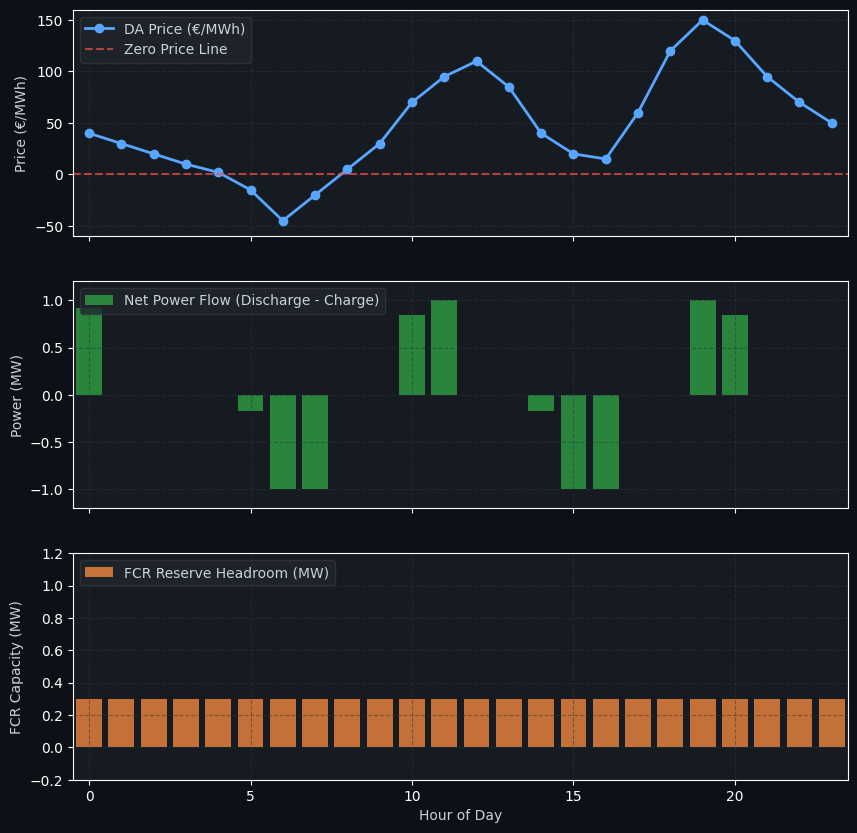

In [9]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Set dark theme style
plt.style.use('dark_background')
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig.patch.set_facecolor('#0d1117')

hours = np.arange(24)
prices_da = np.array([40, 30, 20, 10, 2, -15, -45, -20, 5, 30, 70, 95,
                      110, 85, 40, 20, 15, 60, 120, 150, 130, 95, 70, 50])
fcr_cap = np.array([0.3] * 24)
charge = np.array([0, 0, 0, 0, 0, 0.174, 1.0, 1.0, 0, 0, 0, 0, 0, 0, 0.174, 1.0, 1.0, 0, 0, 0, 0, 0, 0, 0])
discharge = np.array([0.92, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.84, 1.0, 0, 0, 0, 0, 0, 0, 0, 1.0, 0.84, 0, 0, 0])

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor('#161b22')
    ax.grid(True, color='#30363d', linestyle='--', alpha=0.5)

# Plot elements setup
line1, = ax1.plot([], [], color='#58a6ff', lw=2, marker='o', label='DA Price (€/MWh)')
ax1.axhline(0, color='#f85149', linestyle='--', alpha=0.7, label='Zero Price Line')
ax1.set_ylabel('Price (€/MWh)', color='#c9d1d9')
ax1.set_ylim(-60, 160)
ax1.legend(loc='upper left', facecolor='#21262d', edgecolor='#30363d', labelcolor='#c9d1d9')

bars1 = ax2.bar(hours, np.zeros(24), color='#2ea043', alpha=0.8, label='Net Power Flow (Discharge - Charge)')
ax2.set_ylabel('Power (MW)', color='#c9d1d9')
ax2.set_ylim(-1.2, 1.2)
ax2.legend(loc='upper left', facecolor='#21262d', edgecolor='#30363d', labelcolor='#c9d1d9')

bars2 = ax3.bar(hours, np.zeros(24), color='#f0883e', alpha=0.8, label='FCR Reserve Headroom (MW)')
ax3.set_ylabel('FCR Capacity (MW)', color='#c9d1d9')
ax3.set_xlabel('Hour of Day', color='#c9d1d9')
ax3.set_xlim(-0.5, 23.5)
ax3.set_ylim(-0.2, 1.2)
ax3.legend(loc='upper left', facecolor='#21262d', edgecolor='#30363d', labelcolor='#c9d1d9')

def init():
    line1.set_data([], [])
    return line1,

def update(frame):
    current_hours = hours[:frame+1]
    line1.set_data(current_hours, prices_da[:frame+1])

    for i, b in enumerate(bars1):
        if i <= frame:
            b.set_height(discharge[i] - charge[i])
        else:
            b.set_height(0)

    for i, b in enumerate(bars2):
        if i <= frame:
            b.set_height(fcr_cap[i])
        else:
            b.set_height(0)

    return line1, *bars1, *bars2

ani = animation.FuncAnimation(fig, update, frames=len(hours), init_func=init, interval=150, blit=True)
ani.save('bess_co_optimization_dark.gif', writer='pillow', fps=6)
print("Dark-themed multi-market co-optimization GIF successfully generated with correct axis limits!")